# 01 — Load & Data Quality

## 1. Contexte et objectif
- Charger `base1.csv`
- Parser le timestamp `t` (mix ISO string / unix seconds)
- Standardiser les noms de colonnes
- Contrôles qualité : ordre temporel, doublons, fréquence 2h, trous, manquants, plausibilité
- Exporter une version **parsed** (pas nettoyée) pour `02_cleaning.ipynb`

## 2. Imports & configuration

In [1]:
# Import
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (10, 4)

# Paths
PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "base1.csv"
INTERIM_PATH = PROJECT_ROOT / "data" / "interim" / "base1_parsed.parquet"
INTERIM_PATH.parent.mkdir(parents=True, exist_ok=True)

# import pipeline function from src/
sys.path.append(str(PROJECT_ROOT / "src"))
from data import prepare_base1

## 3. Chargement brut
On charge le CSV brut et on vérifie la structure (shape, colonnes, types).

In [2]:
rename_map = {
    "Unnamed: 0": "row_id",
    "t": "ts_raw",
    "date": "date_raw",
    "id_sonde": "id_sonde",
    "Teau": "temp_water_c",
    "Tair.EOBS": "temp_air_eobs_c",
    "Rainf.EOBS": "rainf_eobs",
    "Q.qjm": "discharge_q_qjm",
    "Q": "discharge_q",
    "Qmmj": "discharge_q_mmj",
    "rr.REF.EOBS": "rain_rr_ref_eobs",
    "rr.MEAN.EOBS": "rain_rr_mean_eobs",
    "tg.REF.EOBS": "temp_tg_ref_eobs",}

if INTERIM_PATH.exists():
    print("interim déjà prêt, on charge:", INTERIM_PATH)
    df = pd.read_parquet(INTERIM_PATH)
    qc = None
else:
    print("Création interim:", INTERIM_PATH)
    df, qc = prepare_base1(
        raw_path=DATA_PATH,
        interim_path=INTERIM_PATH,
        rename_map=rename_map,
        raw_ts_col="ts_raw",
        station_col="id_sonde",)
    print("QC:", qc)


interim déjà prêt, on charge: ..\data\interim\base1_parsed.parquet


In [3]:
print("Shape:", df.shape)
display(df.head(5))

print("\nColonnes:")
print(list(df.columns))


Shape: (164206, 15)


,row_id,id_sonde,ts,date,ts_raw,date_raw,temp_water_c,temp_air_eobs_c,rainf_eobs,discharge_q,discharge_q_qjm,discharge_q_mmj,rain_rr_ref_eobs,rain_rr_mean_eobs,temp_tg_ref_eobs
0,46917,817,2013-05-29 14:00:00,2013-05-29,2013-05-29 14:00:00,2013-05-29,12.703,9.75,2.8,18.1,18.1,0.717358,2.8,3.360976,9.75
1,46918,817,2013-05-29 16:00:00,2013-05-29,2013-05-29 16:00:00,2013-05-29,12.896,9.75,2.8,18.1,18.1,0.717358,2.8,3.360976,9.75
2,46919,817,2013-05-29 18:00:00,2013-05-29,2013-05-29 18:00:00,2013-05-29,12.968,9.75,2.8,18.1,18.1,0.717358,2.8,3.360976,9.75
3,46920,817,2013-05-29 20:00:00,2013-05-29,2013-05-29 20:00:00,2013-05-29,12.920,9.75,2.8,18.1,18.1,0.717358,2.8,3.360976,9.75
4,46921,817,2013-05-29 22:00:00,2013-05-29,2013-05-29 22:00:00,2013-05-29,12.799,9.75,2.8,18.1,18.1,0.717358,2.8,3.360976,9.75



Colonnes:
['row_id', 'id_sonde', 'ts', 'date', 'ts_raw', 'date_raw', 'temp_water_c', 'temp_air_eobs_c', 'rainf_eobs', 'discharge_q', 'discharge_q_qjm', 'discharge_q_mmj', 'rain_rr_ref_eobs', 'rain_rr_mean_eobs', 'temp_tg_ref_eobs']


In [4]:
print("Dtypes:")
display(df.dtypes)

Dtypes:


row_id                        int64
id_sonde                      int64
ts                   datetime64[ns]
date                 string[python]
ts_raw                       object
date_raw                     object
temp_water_c                float64
temp_air_eobs_c             float64
rainf_eobs                  float64
discharge_q                 float64
discharge_q_qjm             float64
discharge_q_mmj             float64
rain_rr_ref_eobs            float64
rain_rr_mean_eobs           float64
temp_tg_ref_eobs            float64
dtype: object

In [5]:
print("\nInfo rapide:")
df.info()


Info rapide:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164206 entries, 0 to 164205
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   row_id             164206 non-null  int64         
 1   id_sonde           164206 non-null  int64         
 2   ts                 164206 non-null  datetime64[ns]
 3   date               164206 non-null  string        
 4   ts_raw             164206 non-null  object        
 5   date_raw           164206 non-null  object        
 6   temp_water_c       164206 non-null  float64       
 7   temp_air_eobs_c    164206 non-null  float64       
 8   rainf_eobs         164206 non-null  float64       
 9   discharge_q        163188 non-null  float64       
 10  discharge_q_qjm    163654 non-null  float64       
 11  discharge_q_mmj    163188 non-null  float64       
 12  rain_rr_ref_eobs   163392 non-null  float64       
 13  rain_rr_mean_eobs  163392 non-

**Résultat du chargement brut.** 
- Le fichier contient 164 206 observations pour 13 variables.  
- Les variables `t` et `date` sont chargées en type `object` (texte) : on va donc **convertir `t` en vraie date/heure** de manière robuste (car `t` peut être au format ISO ou au format Unix), puis **reconstruire `date` à partir de `t`** pour garantir la cohérence temporelle.  
- Quelques variables hydrométéo présentent un faible taux de valeurs manquantes (≈0,3–0,6%), ce qui sera traité dans l’étape de nettoyage.


### Dictionnaire rapide des variables (après renommage) : 

- `row_id` : identifiant de ligne (technique).
- `id_sonde` : identifiant du capteur / station.
- `ts_raw` : timestamp brut (à parser : mix formats).
- `date_raw` : date brute (sera reconstruite depuis `ts`).

#### Variable cible
- `temp_water_c` : température de l’eau (°C) — **cible principale**.

#### Variables exogènes (météo / hydro)
- `temp_air_eobs_c` : température de l’air (°C) — source E-OBS.
- `rainf_eobs` : pluie / précipitations — source E-OBS.
- `discharge_q` : débit .
- `discharge_q_qjm` : variable débit dérivée 
- `discharge_q_mmj` : variable débit dérivée .
- `rain_rr_ref_eobs` : variable pluie E-OBS 
- `rain_rr_mean_eobs` : variable pluie E-OBS .
- `temp_tg_ref_eobs` : variable température E-OBS.


## 4. Parsing du temps + reconstruction de `date`

On parse `ts_raw` (formats mixtes) en `ts` (datetime) puis on reconstruit `date` depuis `ts` pour garantir la cohérence temporelle.


In [6]:
# parsing du temps est déjà fait dans src/data.py (prepare_base1)
# Ici on vérifie juste que 'ts' et 'date' existent et on affiche un aperçu
assert 'ts' in df.columns, "La colonne 'ts' n'existe pas: vérifie prepare_base1()"
if 'date' not in df.columns:
    df['date'] = df['ts'].dt.date.astype('string')

print('NaT dans ts:', df['ts'].isna().sum())
print('Min ts:', df['ts'].min())
print('Max ts:', df['ts'].max())
display(df[[c for c in ['id_sonde','ts_raw','ts','date_raw','date'] if c in df.columns]].head(5))


NaT dans ts: 0
Min ts: 2013-05-29 14:00:00
Max ts: 2018-10-05 08:00:00


,id_sonde,ts_raw,ts,date_raw,date
0,817,2013-05-29 14:00:00,2013-05-29 14:00:00,2013-05-29,2013-05-29
1,817,2013-05-29 16:00:00,2013-05-29 16:00:00,2013-05-29,2013-05-29
2,817,2013-05-29 18:00:00,2013-05-29 18:00:00,2013-05-29,2013-05-29
3,817,2013-05-29 20:00:00,2013-05-29 20:00:00,2013-05-29,2013-05-29
4,817,2013-05-29 22:00:00,2013-05-29 22:00:00,2013-05-29,2013-05-29


**Parsing temporel.** Le timestamp `ts_raw` (format mixte) a été converti en datetime `ts` sans perte (`NaT = 0`).  
La période couverte s’étend de 2013-05-29 à 2018-10-05. La variable `date` est reconstruite depuis `ts` afin d’assurer la cohérence temporelle (la colonne `date_raw` n’est pas utilisée pour l’analyse).

## 5. Contrôles qualité

### 5.1 Qualité temporelle : doublons, fréquence 2h, gaps

In [7]:
EXPECTED_HOURS = 2

#  Doublon (id_sonde, ts)
n_dup = df.duplicated(subset=["id_sonde", "ts"]).sum()
print("Doublon (id_sonde, ts):", int(n_dup))

# Rapport par station : fréquence et gaps
rows = []
for sid, g in df.groupby("id_sonde", sort=True):
    g = g.sort_values("ts")
    dt_hours = g["ts"].diff().dt.total_seconds() / 3600.0

    # stats sur les deltas
    n_steps = dt_hours.notna().sum()
    pct_2h = (dt_hours == EXPECTED_HOURS).mean() * 100 if n_steps > 0 else np.nan

    gaps = dt_hours[dt_hours > EXPECTED_HOURS]
    n_gaps = int(gaps.count())
    max_gap = float(gaps.max()) if n_gaps > 0 else 0.0

    n_unique = g["ts"].nunique()
    expected_len = len(pd.date_range(g["ts"].min(), g["ts"].max(), freq=f"{EXPECTED_HOURS}h"))
    missing_expected = int(expected_len - n_unique)

    rows.append({
        "id_sonde": sid,
        "n_rows": int(len(g)),
        "n_unique_ts": int(n_unique),
        "min_ts": g["ts"].min(),
        "max_ts": g["ts"].max(),
        "pct_step_2h": round(pct_2h, 2),
        "n_gaps_gt_2h": n_gaps,
        "max_gap_hours": round(max_gap, 2),
        "missing_expected_steps": missing_expected,})

quality_time = pd.DataFrame(rows).sort_values("id_sonde").reset_index(drop=True)
display(quality_time)

#  aperçu des plus gros trous (top 10) sur tout le dataset
tmp = df.sort_values(["id_sonde", "ts"]).copy()
tmp["delta_h"] = tmp.groupby("id_sonde")["ts"].diff().dt.total_seconds() / 3600.0
big_gaps = tmp[tmp["delta_h"] > EXPECTED_HOURS].sort_values("delta_h", ascending=False)

if big_gaps.empty:
    print("aaucun gap > 2h détecté (big_gaps vide).")
else:
    display(big_gaps[["id_sonde", "ts", "delta_h"]].head(10))

Doublon (id_sonde, ts): 0


,id_sonde,n_rows,n_unique_ts,min_ts,max_ts,pct_step_2h,n_gaps_gt_2h,max_gap_hours,missing_expected_steps
0,817,23458,23458,2013-05-29 14:00:00,2018-10-05 08:00:00,100.0,0,0.0,0
1,818,23458,23458,2013-05-29 14:00:00,2018-10-05 08:00:00,100.0,0,0.0,0
2,819,23458,23458,2013-05-29 14:00:00,2018-10-05 08:00:00,100.0,0,0.0,0
3,825,23458,23458,2013-05-29 14:00:00,2018-10-05 08:00:00,100.0,0,0.0,0
4,827,23458,23458,2013-05-29 14:00:00,2018-10-05 08:00:00,100.0,0,0.0,0
5,828,23458,23458,2013-05-29 14:00:00,2018-10-05 08:00:00,100.0,0,0.0,0
6,830,23458,23458,2013-05-29 14:00:00,2018-10-05 08:00:00,100.0,0,0.0,0


aaucun gap > 2h détecté (big_gaps vide).


**Qualité temporelle.** 
- Aucun doublon n’est détecté sur la clé (`id_sonde`, `ts`).  
- Pour chaque station, la série est strictement régulière avec un pas de 2 heures (100% des deltas = 2h) et aucun trou temporel n’a été observé (`n_gaps_gt_2h = 0`, `missing_expected_steps = 0`).  
- Cela garantit une base solide pour l’EDA et la modélisation (pas besoin de reconstituer un calendrier temporel).

### 5.2 Valeurs manquantes (global + par station)

In [8]:
missing_global = (df.isna().mean() * 100).sort_values(ascending=False).to_frame("pct_missing")
missing_global["n_missing"] = df.isna().sum()
missing_global["dtype"] = df.dtypes.astype(str)

print("Missing global (%):")
display(missing_global)

df_no_group = df.drop(columns=["id_sonde"])

missing_by_station = (
    df_no_group.isna()
      .groupby(df["id_sonde"])
      .mean()
      .mul(100))

# on remet id_sonde en col proprement
missing_by_station = missing_by_station.reset_index()

missing_by_station_long = (
    missing_by_station
      .melt(id_vars="id_sonde", var_name="variable", value_name="pct_missing")
      .sort_values(["pct_missing", "id_sonde"], ascending=[False, True])
      .reset_index(drop=True))

print("Top 10 (station-variable) en % manquants :")
display(missing_by_station_long.head(10))


Missing global (%):


,pct_missing,n_missing,dtype
discharge_q,0.619953,1018,float64
discharge_q_mmj,0.619953,1018,float64
rain_rr_ref_eobs,0.495719,814,float64
rain_rr_mean_eobs,0.495719,814,float64
temp_tg_ref_eobs,0.495719,814,float64
discharge_q_qjm,0.336163,552,float64
row_id,0.000000,0,int64
id_sonde,0.000000,0,int64
ts,0.000000,0,datetime64[ns]
date,0.000000,0,string


Top 10 (station-variable) en % manquants :


,id_sonde,variable,pct_missing
0,827,discharge_q,1.197886
1,827,discharge_q_mmj,1.197886
2,828,discharge_q,1.197886
3,828,discharge_q_mmj,1.197886
4,825,discharge_q,1.125416
5,825,discharge_q_mmj,1.125416
6,825,rain_rr_ref_eobs,1.023105
7,825,rain_rr_mean_eobs,1.023105
8,825,temp_tg_ref_eobs,1.023105
9,827,rain_rr_ref_eobs,0.942109


**Valeurs manquantes.** 
- La variable cible `temp_water_c` ne présente aucune valeur manquante (0%).  
- Les valeurs manquantes concernent principalement les variables exogènes (débit et variables E-OBS) avec des taux faibles : ~0,34% à ~0,62% au global.  
- Par station, les taux maximum observés restent limités (~1,20% sur `discharge_q` / `discharge_q_mmj` pour les stations 827 et 828, ~1,12% pour la station 825).  
- Ces manquants seront traités lors de l’étape de nettoyage (par station, sans fuite) afin de garantir la compatibilité avec les modèles exogènes (régression, SARIMAX).


### 5.3 Contrôle de plausibilité (valeurs extrêmes / incohérences)

**Objectif.** Vérifier que les variables clés (cible + exogènes) prennent des valeurs plausibles avant tout nettoyage/modélisation, via des statistiques robustes (min/max, quantiles) et des compteurs de valeurs hors bornes.

**Pourquoi c’est important.** Des valeurs aberrantes (capteur défaillant, unité incohérente, valeurs négatives impossibles pour pluie/débit) peuvent biaiser l’EDA et dégrader fortement les modèles (régression, SARIMAX), même si elles sont rares.


In [9]:
# Stats + quantiles de par station
qs = [0.01, 0.05, 0.50, 0.95, 0.99]

temp_plaus = (
    df.groupby("id_sonde")["temp_water_c"]
      .agg(["count", "mean", "std", "min", "max"])
      .join(
          df.groupby("id_sonde")["temp_water_c"]
            .quantile(qs)
            .unstack()
            .rename(columns=lambda q: f"q{int(q*100):02d}"))
      .round(3)
      .reset_index())

display(temp_plaus)

# Plages plausibles (heuristiques) pour repérer les valeurs aberrante
ranges = {
    "temp_water_c": (-2, 35),
    "temp_air_eobs_c": (-30, 45),
    "rainf_eobs": (0, np.inf),
    "discharge_q": (0, np.inf),}

rows = []
for col, (lo, hi) in ranges.items():
    if col not in df.columns:
        continue
    x = df[col]
    out = ((x < lo) | (x > hi)) & x.notna()
    rows.append({
        "variable": col,
        "n_out": int(out.sum()),
        "pct_out": round(100 * out.sum() / x.notna().sum(), 4),
        "lo": lo,
        "hi": hi})

out_of_range_global = pd.DataFrame(rows).sort_values("pct_out", ascending=False)
display(out_of_range_global)

out_y = df[(df["temp_water_c"] < -2) | (df["temp_water_c"] > 35)][["id_sonde", "ts", "temp_water_c"]]
display(out_y.head(20))


,id_sonde,count,mean,std,min,max,q01,q05,q50,q95,q99
0,817,23458,13.126,5.400,0.218,26.182,2.021,5.205,12.980,21.537,23.160
1,818,23458,13.392,5.514,0.770,25.817,2.385,5.257,13.257,21.939,23.545
2,819,23458,13.238,5.586,0.570,25.812,2.185,5.031,13.105,21.834,23.585
3,825,23458,11.262,3.022,3.591,18.438,4.947,6.560,11.467,15.772,16.820
4,827,23458,11.419,3.295,1.398,20.341,4.339,6.102,11.686,16.296,17.558
5,828,23458,11.702,3.729,0.632,21.557,3.354,5.770,11.929,17.249,18.628
6,830,23458,12.302,3.696,1.507,22.968,4.115,6.687,12.364,17.938,19.460


,variable,n_out,pct_out,lo,hi
0,temp_water_c,0,0.0,-2,35.0
1,temp_air_eobs_c,0,0.0,-30,45.0
2,rainf_eobs,0,0.0,0,inf
3,discharge_q,0,0.0,0,inf


,id_sonde,ts,temp_water_c


**Plausibilité des valeurs.** 

- Aucun enregistrement n’est détecté hors des bornes physiques fixées (0% out-of-range) pour la température de l’eau, la température de l’air et les variables pluie/débit (non-négativité respectée).

**Température de l’eau — contraste inter-stations.** 
- Les stations 817/818/819 présentent des maxima proches de 26°C et des minima proches de 0–1°C (variabilité saisonnière forte), tandis que les stations 825/827/828/830 sont plus “froides” et moins variables. La station 825 se distingue notamment (min 3.59°C, max 18.44°C, écart-type ~3.0°C), suggérant un effet local (ex. inertie, ombrage, apports de nappe), à investiguer en EDA.


## 6. Contrôle dynamique (spikes & plateaux)

**Objectif.** Détecter des anomalies temporelles non visibles via les bornes (pics rapides et capteurs figés), en analysant la variation entre deux pas de 2 heures.

**Méthode.**
- `dTeau(t) = Teau(t) - Teau(t-2h)` par station.
- Spikes : `|dTeau| > seuil` (seuil initial conservateur).
- Plateaux : longues séquences consécutives avec `Teau` inchangée.

**Sorties attendues.**
- Nombre de spikes et exemples des plus grands.
- Nombre de plateaux longs (≥ 24h) et leurs périodes.

In [10]:
THRESH_SPIKE = 3.0      # °C / 2h (seuil init)
PLATEAU_STEPS = 12      # 12 pas de 2h = 24h

tmp = df.sort_values(["id_sonde", "ts"]).copy()
tmp["dtemp_2h"] = tmp.groupby("id_sonde")["temp_water_c"].diff()

# Spikes
spikes = tmp[tmp["dtemp_2h"].abs() > THRESH_SPIKE]
print(f"Spikes |dTeau| > {THRESH_SPIKE} °C/2h :", len(spikes))
display(spikes.loc[:, ["id_sonde", "ts", "temp_water_c", "dtemp_2h"]]
            .sort_values("dtemp_2h", key=lambda s: s.abs(), ascending=False)
            .head(10))

# Plateaux (Teau constant)
tmp["is_flat"] = tmp.groupby("id_sonde")["temp_water_c"].diff().fillna(0).eq(0)
plateau_list = []
for sid, g in tmp.groupby("id_sonde"):
    run = (g["is_flat"] != g["is_flat"].shift()).cumsum()
    runs = g.groupby(run).agg(is_flat=("is_flat","first"),
                              run_len=("is_flat","size"),
                              start_ts=("ts","min"),
                              end_ts=("ts","max"))
    long_flat = runs[(runs["is_flat"]) & (runs["run_len"] >= PLATEAU_STEPS)].copy()
    if not long_flat.empty:
        long_flat["id_sonde"] = sid
        plateau_list.append(long_flat.reset_index(drop=True))

plateaus = pd.concat(plateau_list, ignore_index=True) if plateau_list else pd.DataFrame()
print(f"Plateaux >= {PLATEAU_STEPS} pas (≈24h) :", len(plateaus))
if not plateaus.empty:
    display(plateaus.sort_values("run_len", ascending=False).head(10))


Spikes |dTeau| > 3.0 °C/2h : 1


,id_sonde,ts,temp_water_c,dtemp_2h
5537,817,2014-09-03,13.882,-3.367


Plateaux >= 12 pas (≈24h) : 0


**Contrôle dynamique.** 

- Un seul spike a été détecté avec `|dTeau| > 3°C/2h` (station 817, variation -3.367°C autour du 2014-09-03). Aucun plateau long (capteur figé ≥ 24h) n’a été observé.  
- Globalement, la série est très stable et régulière ; l’anomalie ponctuelle sera inspectée puis éventuellement traitée lors de l’étape de nettoyage.


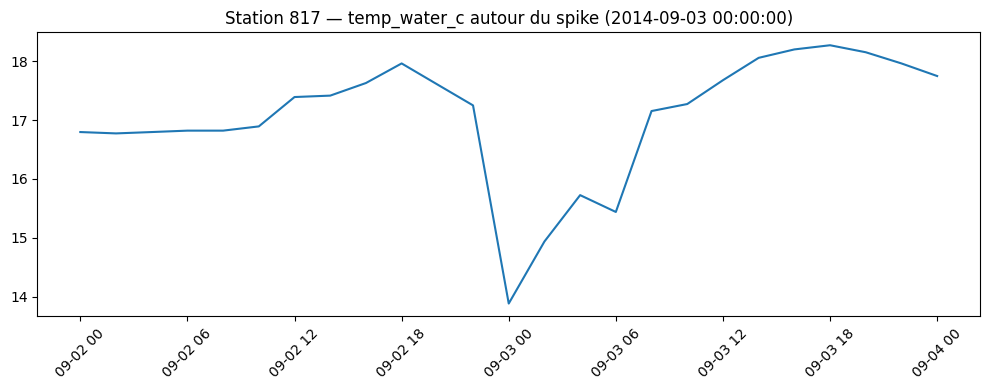

In [11]:
# zoom plot autour du spike
sid = 817
t0 = pd.Timestamp("2014-09-03 00:00:00")

g = df[df["id_sonde"] == sid].sort_values("ts")
w = g[(g["ts"] >= t0 - pd.Timedelta(hours=24)) & (g["ts"] <= t0 + pd.Timedelta(hours=24))]

plt.figure()
plt.plot(w["ts"], w["temp_water_c"])
plt.title(f"Station {sid} — temp_water_c autour du spike ({t0})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Mini-EDA brute 

Objectif : vérifier visuellement la cohérence du signal (saisonnalité, différences inter-stations) avec quelques figures simples, sans encore faire d’EDA avancée.


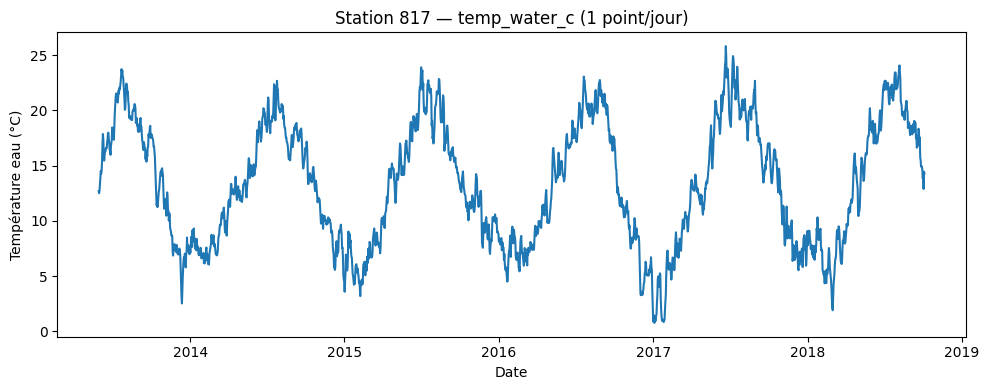

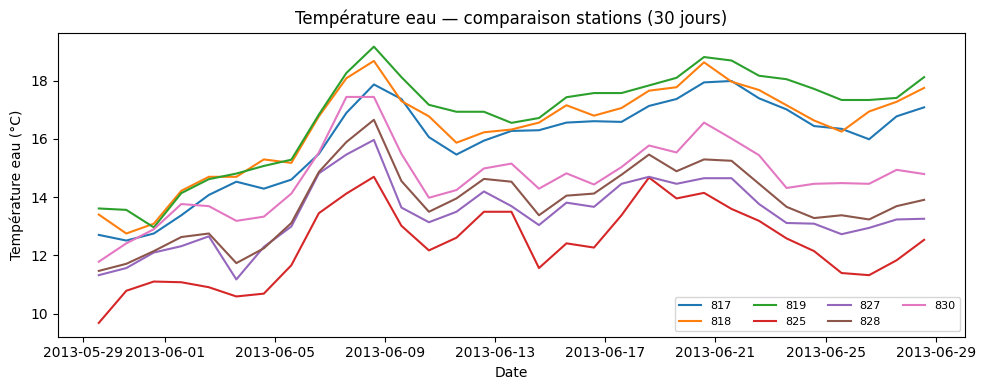

<Figure size 1000x400 with 0 Axes>

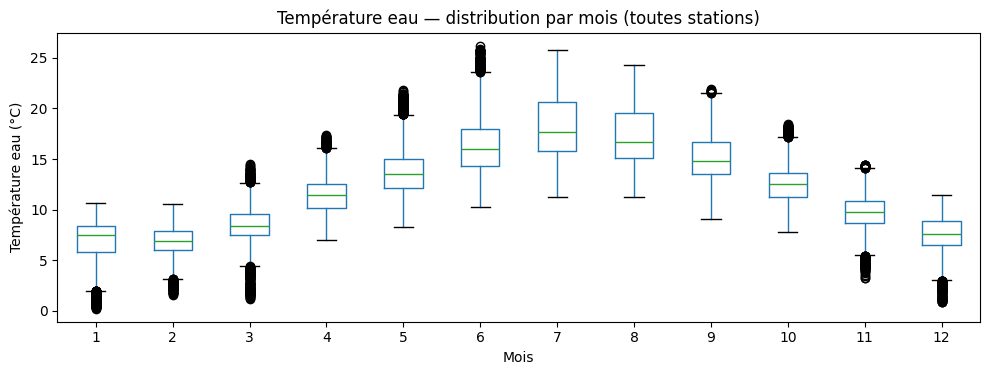

In [12]:

sid = df["id_sonde"].iloc[0]  
g = df[df["id_sonde"] == sid].sort_values("ts")

step = 12  
plt.figure()
plt.plot(g["ts"].iloc[::step], g["temp_water_c"].iloc[::step])
plt.title(f"Station {sid} — temp_water_c (1 point/jour)")
plt.xlabel("Date")
plt.ylabel("Température eau (°C)")
plt.tight_layout()
plt.show()

# comparaison stations sur une fenêtre courte 
start = df["ts"].min()
end = start + pd.Timedelta(days=30)
w = df[(df["ts"] >= start) & (df["ts"] <= end)].copy()

plt.figure()
for sid2, gg in w.groupby("id_sonde"):
    gg = gg.sort_values("ts")
    plt.plot(gg["ts"].iloc[::step], gg["temp_water_c"].iloc[::step], label=str(sid2))
plt.title("Température eau — comparaison stations (30 jours)")
plt.xlabel("Date")
plt.ylabel("Température eau (°C)")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

#  Distribution par mois (boxplot)
df_plot = df.copy()
df_plot["month"] = df_plot["ts"].dt.month

plt.figure(figsize=(10, 4))
df_plot.boxplot(column="temp_water_c", by="month", grid=False)
plt.title("Température eau — distribution par mois (toutes stations)")
plt.suptitle("")
plt.xlabel("Mois")
plt.ylabel("Température eau (°C)")
plt.tight_layout()
plt.show()


### Synthèse mini-EDA 

- La série de température d’eau (ex. station 817) présente une **saisonnalité annuelle marquée**, cohérente avec la dynamique attendue (été chaud, hiver froid).
- Le boxplot mensuel (toutes stations) confirme un **cycle saisonnier stable** avec un maximum en été et un minimum en hiver.
- La comparaison inter-stations sur une fenêtre courte montre un **signal commun** (tendance météo) mais aussi des **différences de niveau** entre stations (effets locaux). La station 825 apparaît plus froide et moins variable, ce qui suggère un effet station (ex. conditions locales) à investiguer dans l’EDA avancée.


## 8. Exports (interim) + résumé

Objectif : sauvegarder une version “parsed” reproductible (timestamps parsés, tri station/temps, noms propres) ainsi que les rapports qualité produits dans ce notebook.

In [13]:
cols_order = [
    "row_id", "id_sonde", "ts", "date", "ts_raw", "date_raw",
    "temp_water_c", "temp_air_eobs_c", "rainf_eobs",
    "discharge_q", "discharge_q_qjm", "discharge_q_mmj",
    "rain_rr_ref_eobs", "rain_rr_mean_eobs", "temp_tg_ref_eobs",]
cols_order = [c for c in cols_order if c in df.columns]

df_parsed = df[cols_order].copy()

# Export parquet 

print('Interim parquet:', INTERIM_PATH)

summary = {
    "n_rows": len(df_parsed),
    "n_cols": df_parsed.shape[1],
    "n_stations": df_parsed["id_sonde"].nunique(),
    "min_ts": str(df_parsed["ts"].min()),
    "max_ts": str(df_parsed["ts"].max()),
    "n_dup_station_ts": int(df_parsed.duplicated(["id_sonde", "ts"]).sum()),
    "pct_missing_temp_water_c": float(df_parsed["temp_water_c"].isna().mean() * 100),}

summary_df = pd.DataFrame([summary])
display(summary_df)


Interim parquet: ..\data\interim\base1_parsed.parquet


,n_rows,n_cols,n_stations,min_ts,max_ts,n_dup_station_ts,pct_missing_temp_water_c
0,164206,15,7,2013-05-29 14:00:00,2018-10-05 08:00:00,0,0.0


### Export (interim)

- Les données ont été exportées au format Parquet après parsing temporel, renommage et tri (`base1_parsed.parquet`).  
- Cette version est stockée dans `data/interim/` car elle correspond à une étape **intermédiaire** : la grille temporelle et les types sont validés, mais aucun nettoyage (imputation/outliers) n’a encore été appliqué.  
- Un résumé des contrôles qualité a également été sauvegardé (`summary_load_quality.csv`).
